In [70]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [ ]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 15)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

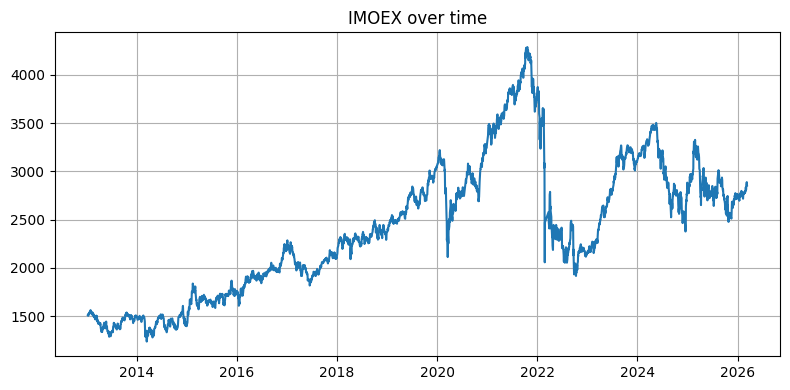

In [71]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [72]:
from src.get_features import add_log_returns, add_volatility, add_drawdown_features

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])
candles = add_drawdown_features(candles, [7, 14, 30, 90, 180])

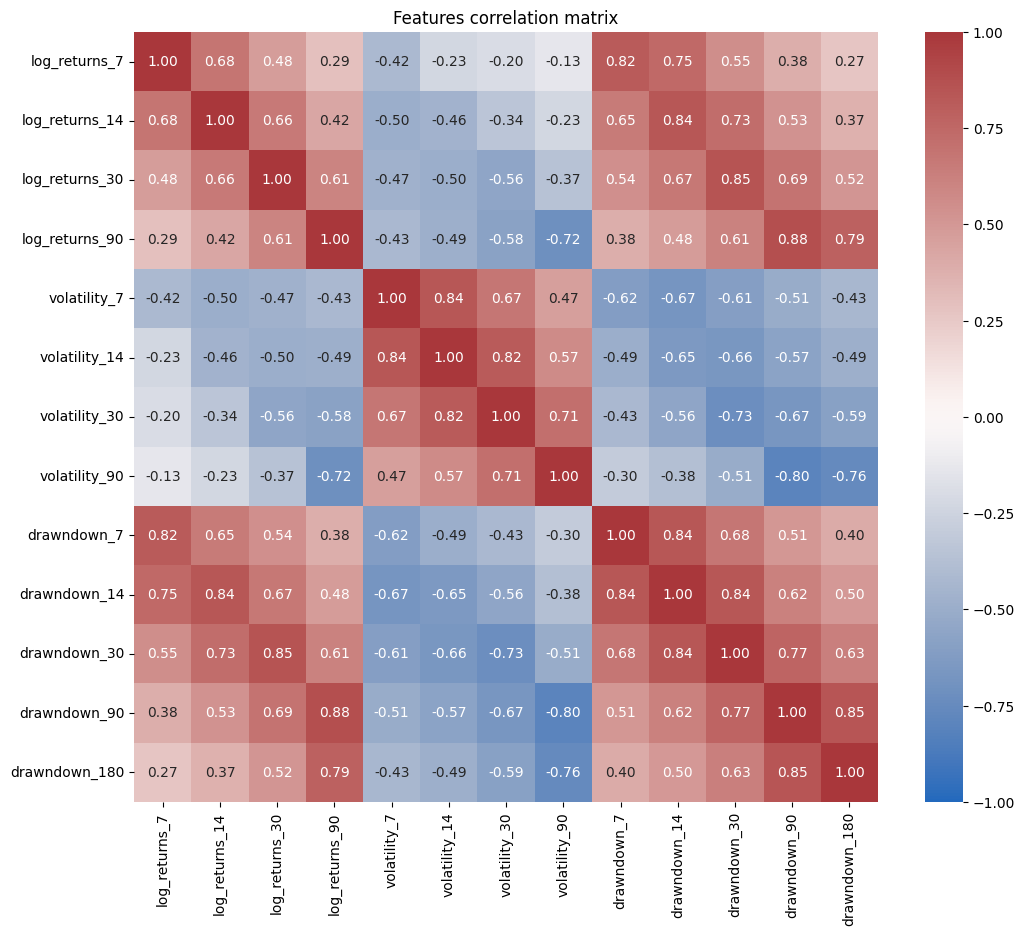

In [73]:
import seaborn as sns

features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90", 
    "drawndown_7", "drawndown_14", "drawndown_30", "drawndown_90", "drawndown_180"
]
features_df = candles[features].dropna()
correlation_matrix_pd = features_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_pd, annot=True, cmap="vlag", fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Features correlation matrix")
plt.show()

Model is not converging.  Current: 139.99777898483467 is not greater than 10894.926894097905. Delta is -10754.929115113071
Model is not converging.  Current: 18344.697488997914 is not greater than 18359.673033890005. Delta is -14.97554489209142
Model is not converging.  Current: 3904.7201711175794 is not greater than 5318.616825477433. Delta is -1413.8966543598535
Model is not converging.  Current: 9985.720640919697 is not greater than 18482.75864191254. Delta is -8497.038000992843
Model is not converging.  Current: 5507.0228193899 is not greater than 8886.470424055015. Delta is -3379.4476046651143
Model is not converging.  Current: 10919.818605807233 is not greater than 15484.279590607934. Delta is -4564.4609848007
Model is not converging.  Current: 9099.52889988143 is not greater than 18948.36239260329. Delta is -9848.833492721858
Model is not converging.  Current: 10491.167055373637 is not greater than 12720.415412946742. Delta is -2229.2483575731057
Model is not converging.  Curren

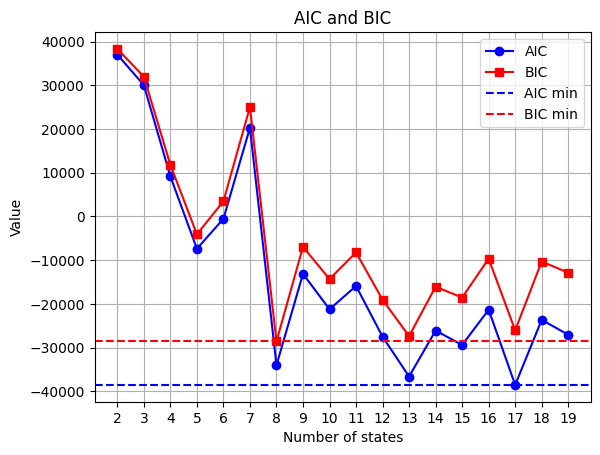

In [74]:
from src.train_hmm import train_hmm
from sklearn.preprocessing import StandardScaler

features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90", 
    "drawndown_7", "drawndown_14", "drawndown_30", "drawndown_90", "drawndown_180"
]

candles = candles.dropna()
X = candles[features].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

bics = []
aics = []
ks = range(2, 15)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [75]:
model = train_hmm(X, n_states=8, n_iter=1000)

Model is not converging.  Current: 1790.5330213288835 is not greater than 5509.224127409863. Delta is -3718.69110608098


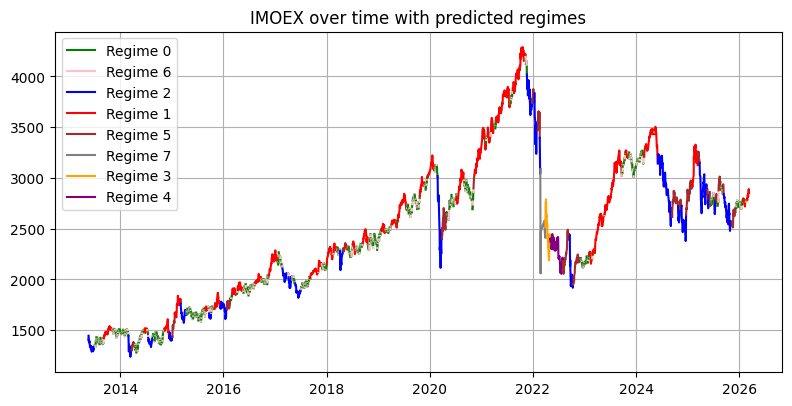

In [76]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [66]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})
x = model.predict_proba(X)[-1]
for i in range(len(x)):
    print(i, x[i])

print(model.predict_proba(X)[-1])
print(statistics)

0 0.0
1 0.0
2 0.0010119335222004342
3 0.0
4 1.1218332891279163e-62
5 9.714559938153119e-25
6 2.2859617963328686e-08
7 9.019799564052672e-78
8 3.7628740446619315e-05
9 1.4174503971206373e-264
10 0.9989504148861705
[0.00000000e+000 0.00000000e+000 1.01193352e-003 0.00000000e+000
 1.12183329e-062 9.71455994e-025 2.28596180e-008 9.01979956e-078
 3.76287404e-005 1.41745040e-264 9.98950415e-001]
       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.004032  0.024616     0.008286  0.003382  1611
1          -0.050566  0.058609     0.019599  0.008550    32
2           0.036186  0.032865     0.011421  0.006059   113
3          -0.007305  0.044720     0.019336  0.007375    62
4          -0.080959  0.158445     0.055978  0.051850    48
5           0.019279  0.050902     0.020593  0.007199    62
6           0.037360  0.035838     0.012984  0.004687    23
7      

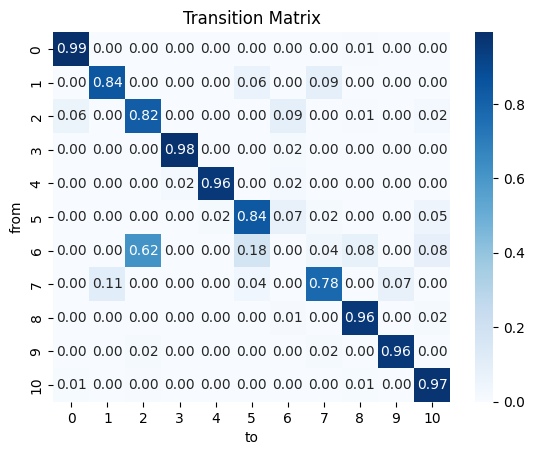

In [59]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")
plt.show()

In [60]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": np.round(expected_duration, 2)
})
print(df)

    Stay Probability  Expected regime duration (days)
0           0.992569                           134.58
1           0.843831                             6.40
2           0.818682                             5.52
3           0.983871                            62.00
4           0.958256                            23.96
5           0.841294                             6.30
6           0.000271                             1.00
7           0.777631                             4.50
8           0.959896                            24.94
9           0.961538                            26.00
10          0.973645                            37.94


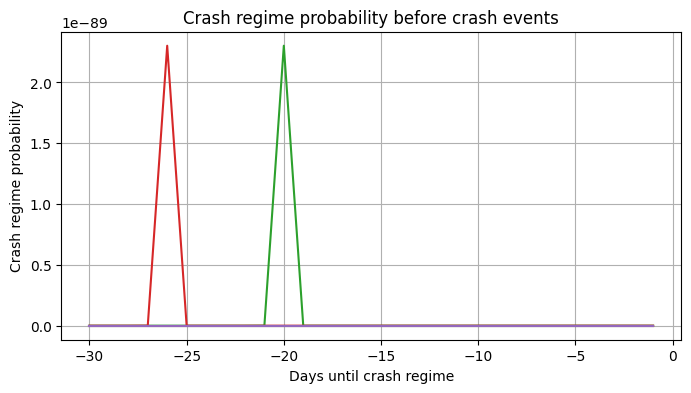

In [61]:
crash_regime = 4
probs = model.predict_proba(X)
crash_prob = probs[:, crash_regime]
candles["crash_prob"] = crash_prob

plt.figure(figsize=(8, 4))
crash_starts = []
for i in range(1, len(regimes)):
    if regimes[i] == 1 and regimes[i-1] != 1:
        crash_starts.append(i)

window = 30
for index in crash_starts:
    start = max(0, index-window)
    end = index
    
    plt.plot(range(-(end-start), 0), crash_prob[start:end])

plt.xlabel("Days until crash regime")
plt.ylabel("Crash regime probability")
plt.title("Crash regime probability before crash events")
plt.grid()

plt.show()